In [1]:
import numpy as np
import pandas as pn

In [2]:
df=pn.read_csv("Titanic-Dataset.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [11]:
df_new = df.copy()
df_new

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [12]:
df_new.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [13]:
df_new = df.copy()
df_new['Age'] = df_new['Age'].fillna(round(df_new['Age'].mean()))
df_new.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [14]:
import numpy as np
outliers = []
def detect_outliers_zscore(data):
    thresh = 2
    mean = np.mean(data)
    #print mean
    std = np.std(data)
    #print std
    for i in data:
        z_score = (i-mean)/std
        #print z-score
        if(z_score > thresh or z_score < -thresh):
            outliers.append(i)
        #print outlier
    return outliers
sample_outliers = detect_outliers_zscore(df['Age'])
print(len(sample_outliers))

index_to_drop = df_new[df_new['Age'].isin(sample_outliers)].index

df_new.drop(index_to_drop,inplace=True)

29


In [18]:
#IQR
import numpy as np
outliers = []
def detect_outliers_zscore(data):
    q1 = np.percentile(data,25)
    q3 = np.percentile(data,75)
    #print(q1,q3)
    IQR = q3 - q1
    lower_bound = q1 - (1.5*IQR)
    upper_bound = q3 + (1.5*IQR)
    #print(lower-bound,upper_bound)
    for i in data:
        if(i<lower_bound or i>upper_bound):
            outliers.append(i)
    return outliers
sample_outliers = detect_outliers_zscore(df['Age'])
#print(sample_outliers)
index_to_drop = df_new[df_new['Age'].isin(sample_outliers)].index
df_new.drop(index_to_drop,inplace=True)
print(df_new)

     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                                 ...     ...   ... 

{'whiskers': [<matplotlib.lines.Line2D at 0x14acf21f250>,
 'caps': [<matplotlib.lines.Line2D at 0x14acf21f790>,
 'boxes': [<matplotlib.lines.Line2D at 0x14acf21de70>],
 'medians': [<matplotlib.lines.Line2D at 0x14acf21fcd0>],
 'fliers': [<matplotlib.lines.Line2D at 0x14acf21ff70>],
 'means': []}

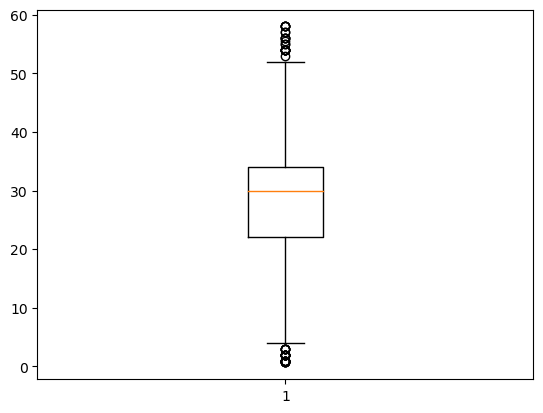

In [20]:
import matplotlib.pyplot as plt
plt.boxplot(df_new['Age'])